## **Load Data**

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập cấu hình hiển thị
plt.style.use('seaborn-v0_8')
%matplotlib inline

# categories, products, clicks, views, purchases, queries

categories = pd.read_csv('/Users/macbook/Documents/2Nam3/MLOPsPr/Kaglle/product-categories.csv', sep=';') #2mb, thiếu biến productCategoryID (serial) 
products = pd.read_csv('/Users/macbook/Documents/2Nam3/MLOPsPr/Kaglle/products.csv', sep=';') # 7.3mb, thiếu biến imageName (name of the corresponding product image) tại chưa cần
clicks = pd.read_csv('/Users/macbook/Documents/2Nam3/MLOPsPr/Kaglle/train-clicks.csv', sep=';') #22.5mb, file này bản gốc không có
views = pd.read_csv('/Users/macbook/Documents/2Nam3/MLOPsPr/Kaglle/train-item-views.csv', sep=';') # 42.7mb, file này đủ
purchases = pd.read_csv('/Users/macbook/Documents/2Nam3/MLOPsPr/Kaglle/train-purchases.csv', sep=';') #750kb, file này có thêm biến userID
queries = pd.read_csv('/Users/macbook/Documents/2Nam3/MLOPsPr/Kaglle/train-queries.csv', sep=';') # 860mb, file này thiếu regionID

/var/folders/dm/fk87zbb17nzb594pksfvrc4c0000gn/T/ipykernel_37523/2580449323.py:17: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  queries = pd.read_csv('/Users/macbook/Documents/2Nam3/MLOPsPr/Kaglle/train-queries.csv', sep=';') # 860mb, file này thiếu regionID


In [58]:
from datetime import datetime
views['eventdate'] = pd.to_datetime(views['eventdate'])
purchases['eventdate'] = pd.to_datetime(purchases['eventdate'])
queries['eventdate'] = pd.to_datetime(queries['eventdate'])

## **EDA**

In [59]:
categories

,itemId,categoryId
0,139578,1096
1,417975,1096
2,291805,1096
3,396921,1096
4,159257,1096
...,...,...
184042,384760,527
184043,386702,527
184044,384854,527
184045,128776,654


In [60]:
products

,itemId,pricelog2,product.name.tokens
0,1,10,"4875,776,56689,18212,18212,4896"
1,69585,6,"7583,18117,41805,41805,2371"
2,90939,6,"604,18117,41805,41805,2371"
3,69586,0,"2936,18117,41805,41805,2371"
4,30029,7,"4668,41805,41805,56652"
...,...,...,...
184042,381997,8,"134345,135203,3583,2886,103395"
184043,402737,9,"527890,527815,527815,183393,277935,19123"
184044,388028,10,"527953,15027,15027,527952"
184045,424367,9,"360922,528327,52648,52648,514247"


In [61]:
clicks

,queryId,timeframe,itemId
0,1,16338861,24857
1,46255,16404912,30792
2,46689,3831948,8252
3,46731,16273568,33969
4,46748,4058493,7837
...,...,...,...
1127759,980493,630896,42906
1127760,980493,641403,33312
1127761,980493,49028,33312
1127762,980493,573532,5227


In [62]:
clicks[clicks['timeframe'] == 0]

,queryId,timeframe,itemId


In [63]:
views

,sessionId,userId,itemId,timeframe,eventdate
0,1,NaN,81766,526309,2016-05-09
1,1,NaN,31331,1031018,2016-05-09
2,1,NaN,32118,243569,2016-05-09
3,1,NaN,9654,75848,2016-05-09
4,1,NaN,32627,1112408,2016-05-09
...,...,...,...,...,...
1235375,600684,NaN,42906,632853,2016-04-14
1235376,600684,NaN,33312,643522,2016-04-14
1235377,600684,NaN,33312,52621,2016-04-14
1235378,600684,NaN,5227,575276,2016-04-14


In [64]:
views[views['timeframe'] == 0]

,sessionId,userId,itemId,timeframe,eventdate


In [65]:
views[views['sessionId'] == 1]

,sessionId,userId,itemId,timeframe,eventdate
0,1,NaN,81766,526309,2016-05-09
1,1,NaN,31331,1031018,2016-05-09
2,1,NaN,32118,243569,2016-05-09
3,1,NaN,9654,75848,2016-05-09
4,1,NaN,32627,1112408,2016-05-09
5,1,NaN,33043,173912,2016-05-09
6,1,NaN,12352,329870,2016-05-09
7,1,NaN,35077,390072,2016-05-09
8,1,NaN,36118,487369,2016-05-09
9,1,NaN,129055,991416,2016-05-09


In [66]:
purchases

,sessionId,userId,timeframe,eventdate,ordernumber,itemId
0,150,18278.0,17100868,2016-05-06,16421,25911
1,151,NaN,6454547,2016-05-06,16290,175874
2,156,7.0,1721689387,2016-05-27,21173,35324
3,179,NaN,343001,2016-05-09,16924,31233
4,246,34.0,2311046,2016-05-09,16936,34677
...,...,...,...,...,...,...
18020,600131,NaN,3674676,2016-03-18,5675,40804
18021,600250,NaN,4943513,2016-05-21,19629,33777
18022,600432,NaN,205120,2016-04-25,13928,17176
18023,600432,NaN,205120,2016-04-25,13928,13662


In [67]:
purchases[purchases['sessionId'] == 1]

,sessionId,userId,timeframe,eventdate,ordernumber,itemId


In [68]:
queries

,queryId,sessionId,userId,timeframe,duration,eventdate,searchstring.tokens,categoryId,items,is.test
0,1,1,NaN,16327074,311,2016-05-09,"16655,244087,51531,529597,58153",0,"7518,71,30311,7837,30792,8252,81766,9338,62220...",False
1,2,2,NaN,705527,314,2016-05-09,"528941,529116",0,"70095,15964,8627,134850,32754,100747,74771,314...",False
2,3,3,NaN,0,502,2016-05-09,"133713,16655,138389",0,"59081,51125,9338,9550,32087,62793,2717,10403,3...",True
3,4,4,NaN,0,1092,2016-05-09,"3918,3822,460416,528812,5276,529517,528738",0,"46632,57465,79064,57748,6080,35997,47088,6078,...",False
4,5,5,NaN,102700,266,2016-05-09,"529223,199482",0,"27312,84626,12621,46209,5140,57539,5368,12923,...",False
...,...,...,...,...,...,...,...,...,...,...
923122,980499,600685,NaN,0,407,2016-05-11,NaN,1174,"37197,37877,37878,30493,59914,249161,70728,600...",True
923123,980500,13265,NaN,361805,1203,2016-04-04,NaN,257,"16285,383058,391318,334708,50753,39983,112937,...",False
923124,980501,286379,NaN,953967,3789,2016-04-07,NaN,273,"93417,38387,81656,161236,81657,212080,152555,1...",True
923125,980502,600686,249346.0,0,1581,2016-05-15,NaN,965,"7516,30087,7553,37380,30261,59236,48347,261,20...",True


In [69]:
queries[queries['timeframe'] == 0]

,queryId,sessionId,userId,timeframe,duration,eventdate,searchstring.tokens,categoryId,items,is.test
2,3,3,NaN,0,502,2016-05-09,"133713,16655,138389",0,"59081,51125,9338,9550,32087,62793,2717,10403,3...",True
3,4,4,NaN,0,1092,2016-05-09,"3918,3822,460416,528812,5276,529517,528738",0,"46632,57465,79064,57748,6080,35997,47088,6078,...",False
5,6,6,NaN,0,673,2016-05-09,75084,0,"20519,59225,26264,73191,73331,40988,2165,43303...",False
6,7,7,NaN,0,696,2016-05-09,"104761,249445",0,"152,69920,59248,1941,40639,73816,32742,10276,5...",False
8,9,9,NaN,0,596,2016-04-10,"419743,67793",0,"915,10237,53009,27771,3168,86030,125242,75611,...",True
...,...,...,...,...,...,...,...,...,...,...
923118,980495,469303,189994.0,0,886,2016-02-09,NaN,444,"59134,69919,59135,59248,7735,108619,20776,7006...",False
923121,980498,168396,NaN,0,2208,2016-05-26,NaN,389,"228101,25942,136627,534324,405964,345197,13395...",False
923122,980499,600685,NaN,0,407,2016-05-11,NaN,1174,"37197,37877,37878,30493,59914,249161,70728,600...",True
923125,980502,600686,249346.0,0,1581,2016-05-15,NaN,965,"7516,30087,7553,37380,30261,59236,48347,261,20...",True


In [70]:
queries[queries['sessionId'] == 1]

,queryId,sessionId,userId,timeframe,duration,eventdate,searchstring.tokens,categoryId,items,is.test
0,1,1,NaN,16327074,311,2016-05-09,"16655,244087,51531,529597,58153",0,"7518,71,30311,7837,30792,8252,81766,9338,62220...",False
46248,46255,1,NaN,16396680,999,2016-05-09,"16655,244087,51531,529597,58153",0,"7518,71,30311,7837,30792,8252,81766,9338,62220...",False
46682,46689,1,NaN,3792515,492,2016-05-09,"244087,535273",0,"30254,7837,513,70894,8252,26612,8867,8882,9300...",False
46724,46731,1,NaN,16208824,597,2016-05-09,"16655,244087,51531,529597,58153",0,"7518,71,30311,7837,30792,8252,81766,9338,62220...",False
46741,46748,1,NaN,4047551,681,2016-05-09,"244087,535273",0,"30254,7837,513,70894,8252,26612,8867,8882,9300...",False
46761,46768,1,NaN,10996700,381,2016-05-09,"16655,244087,2886,184555,278750",0,"7837,513,70894,30792,8252,9300,51257,9654,4438...",False
108054,111737,1,NaN,2588016,2982,2016-05-09,NaN,1010,"7518,69648,71,30254,80775,30311,342,7837,81099...",False
127885,132852,1,NaN,5169072,3718,2016-05-09,NaN,1010,"7518,69648,71,30254,80775,30311,342,7837,81099...",False
187432,196431,1,NaN,1664207,3322,2016-05-09,NaN,1010,"7518,69648,71,30254,80775,30311,342,7837,81099...",False
213325,224052,1,NaN,3347227,3925,2016-05-09,NaN,1010,"7518,69648,71,30254,80775,30311,342,7837,81099...",False


## **Tạo bảng tổng hợp tất cả sự kiện của từng phiên**

In [71]:
# Lấy sessionId và timeframe từ các tệp có sẵn sessionId
df_v = views[['sessionId', 'timeframe']]
df_v['action_type'] = 'view'
df_p = purchases[['sessionId', 'timeframe']]
df_p['action_type'] = 'purchase'
df_q = queries[['sessionId', 'timeframe']]
df_q['action_type'] = 'query'


/var/folders/dm/fk87zbb17nzb594pksfvrc4c0000gn/T/ipykernel_37523/1950728286.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['action_type'] = 'view'
/var/folders/dm/fk87zbb17nzb594pksfvrc4c0000gn/T/ipykernel_37523/1950728286.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p['action_type'] = 'purchase'
/var/folders/dm/fk87zbb17nzb594pksfvrc4c0000gn/T/ipykernel_37523/1950728286.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

In [72]:
df_v

,sessionId,timeframe,action_type
0,1,526309,view
1,1,1031018,view
2,1,243569,view
3,1,75848,view
4,1,1112408,view
...,...,...,...
1235375,600684,632853,view
1235376,600684,643522,view
1235377,600684,52621,view
1235378,600684,575276,view


In [73]:
df_p

,sessionId,timeframe,action_type
0,150,17100868,purchase
1,151,6454547,purchase
2,156,1721689387,purchase
3,179,343001,purchase
4,246,2311046,purchase
...,...,...,...
18020,600131,3674676,purchase
18021,600250,4943513,purchase
18022,600432,205120,purchase
18023,600432,205120,purchase


In [74]:
df_q

,sessionId,timeframe,action_type
0,1,16327074,query
1,2,705527,query
2,3,0,query
3,4,0,query
4,5,102700,query
...,...,...,...
923122,600685,0,query
923123,13265,361805,query
923124,286379,953967,query
923125,600686,0,query


In [75]:
# Xử lý tệp clicks (Không có sessionId, phải map qua queryId từ tệp queries)
# Tạo bảng map giữa queryId và sessionId
query_session_map = queries[['queryId', 'sessionId']].drop_duplicates()
df_c = clicks.merge(query_session_map, on='queryId', how='inner')[['sessionId', 'timeframe']]
df_c['action_type'] = 'click'

In [76]:
df_c

,sessionId,timeframe,action_type
0,1,16338861,click
1,1,16404912,click
2,1,3831948,click
3,1,16273568,click
4,1,4058493,click
...,...,...,...
1127759,600684,630896,click
1127760,600684,641403,click
1127761,600684,49028,click
1127762,600684,573532,click


In [101]:
# Chúng ta đưa tất cả về một DataFrame chung để tìm Min và Max của timeframe
all_events = pd.concat([df_v, df_p, df_q, df_c], ignore_index=True)

In [102]:
all_events = all_events.sort_values(by=['sessionId', 'timeframe']).reset_index(drop=True)

## **Bảng tổng hợp tất cả sự kiện của từng phiên**

In [103]:
all_events

,sessionId,timeframe,action_type
0,1,0,query
1,1,74354,click
2,1,75848,view
3,1,173912,view
4,1,243569,view
...,...,...,...
3304291,600685,0,query
3304292,600686,0,query
3304293,600687,0,query
3304294,600687,132863,click


In [104]:
all_events[all_events['sessionId'] == 1]

,sessionId,timeframe,action_type
0,1,0,query
1,1,74354,click
2,1,75848,view
3,1,173912,view
4,1,243569,view
...,...,...,...
68,1,16576897,click
69,1,17363105,query
70,1,17385764,click
71,1,17450823,click


In [105]:
session_journey = all_events.groupby('sessionId').agg(
    start_time=('timeframe', 'min'),
    end_time=('timeframe', 'max'),
    first_action=('action_type', 'first'),  # Hành động đầu tiên của phiên
    last_action=('action_type', 'last'),    # Hành động cuối cùng của phiên
    event_count=('action_type', 'count')    # Tổng số tương tác trong phiên
)

session_journey['duration_ms'] = session_journey['end_time'] - session_journey['start_time']
session_journey['duration_sec'] = session_journey['duration_ms'] / 1000
session_journey['duration_min'] = session_journey['duration_sec'] / 60

## **Bảng Thống kê thời lượng và tương tác phiên**

In [106]:
session_journey

,start_time,end_time,first_action,last_action,event_count,duration_ms,duration_sec,duration_min
sessionId,,,,,,,,
1,0,17491766,query,click,73,17491766,17491.766,291.529433
2,0,1383241,query,query,22,1383241,1383.241,23.054017
3,0,0,query,query,1,0,0.000,0.000000
4,0,21812,query,view,3,21812,21.812,0.363533
5,0,121036,query,view,6,121036,121.036,2.017267
...,...,...,...,...,...,...,...,...
600683,0,273674,query,view,13,273674,273.674,4.561233
600684,0,643522,query,view,9,643522,643.522,10.725367
600685,0,0,query,query,1,0,0.000,0.000000


In [109]:
# Xem đầy đủ các chỉ số thống kê của các cột thời lượng
stats_summary = session_journey[['duration_sec', 'duration_min']].describe()
print(stats_summary)

       duration_sec   duration_min
count  5.739570e+05  573957.000000
mean   2.298297e+04     383.049556
std    3.050172e+05    5083.619663
min    0.000000e+00       0.000000
25%    0.000000e+00       0.000000
50%    6.935400e+01       1.155900
75%    5.053310e+02       8.422183
max    1.324562e+07  220760.264800


In [110]:
# Lọc các phiên có thời lượng lớn hơn 0 trước khi tính trung bình
avg_active_session = session_journey[session_journey['duration_sec'] > 0]['duration_sec'].mean()

print(f"Thời lượng trung bình của các phiên có hoạt động: {avg_active_session:.2f} giây")

Thời lượng trung bình của các phiên có hoạt động: 35567.98 giây


In [111]:
Q1 = session_journey['duration_min'].quantile(0.25)
Q3 = session_journey['duration_min'].quantile(0.75)
IQR = Q3 - Q1

# Định nghĩa ngưỡng trên (thường là Q3 + 1.5 * IQR)
upper_limit = Q3 + 1.5 * IQR

# Lọc bỏ outlier
cleaned_journey = session_journey[session_journey['duration_min'] <= upper_limit]

print(f"Ngưỡng chặn trên: {upper_limit:.2f} phút")
print(cleaned_journey['duration_min'].describe())

Ngưỡng chặn trên: 21.06 phút
count    502228.000000
mean          3.187638
std           4.975998
min           0.000000
25%           0.000000
50%           0.585342
75%           4.482883
max          21.054133
Name: duration_min, dtype: float64


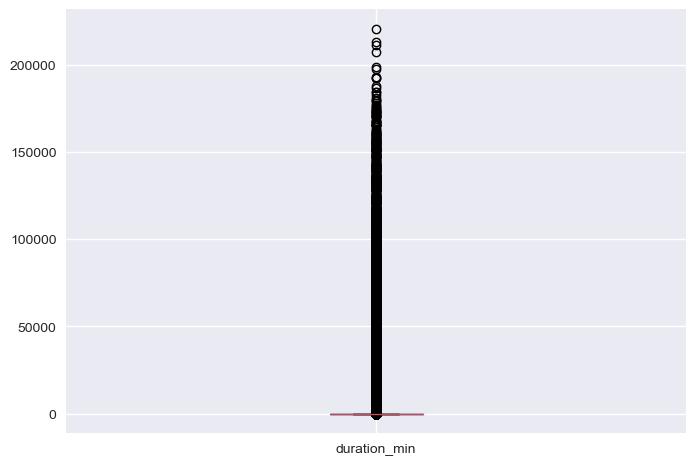

In [112]:
import matplotlib.pyplot as plt
session_journey.boxplot(column=['duration_min'])
plt.show()

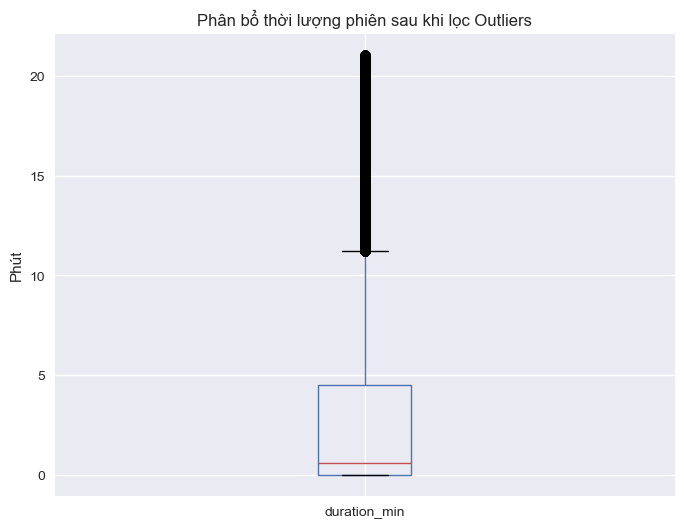

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
cleaned_journey.boxplot(column=['duration_min'])
plt.title('Phân bổ thời lượng phiên sau khi lọc Outliers')
plt.ylabel('Phút')
plt.show()

## **Bảng được lọc các phiên được cho là ngoại lai**

In [117]:
cleaned_journey

,start_time,end_time,first_action,last_action,event_count,duration_ms,duration_sec,duration_min
sessionId,,,,,,,,
3,0,0,query,query,1,0,0.000,0.000000
4,0,21812,query,view,3,21812,21.812,0.363533
5,0,121036,query,view,6,121036,121.036,2.017267
6,0,88337,query,view,4,88337,88.337,1.472283
8,0,140459,query,query,4,140459,140.459,2.340983
...,...,...,...,...,...,...,...,...
600683,0,273674,query,view,13,273674,273.674,4.561233
600684,0,643522,query,view,9,643522,643.522,10.725367
600685,0,0,query,query,1,0,0.000,0.000000


## **Avg Session Duration = 3,19 Minutes or 191,26 Seconds**

In [115]:
# 3. Tính thời lượng trung bình
avg_duration_min = cleaned_journey['duration_min'].mean()
avg_duration_sec = cleaned_journey['duration_sec'].mean()

# 4. Tính thêm trung vị (Median) để so sánh (độ tin cậy cao hơn)
median_duration_min = cleaned_journey['duration_min'].median()

print(f"--- KẾT QUẢ SAU KHI LỌC OUTLIERS (Ngưỡng < {upper_limit:.2f} phút) ---")
print(f"Thời lượng trung bình (Mean): {avg_duration_min:.2f} phút (~{avg_duration_sec:.2f} giây)")
print(f"Thời lượng trung vị (Median): {median_duration_min:.2f} phút")
print(f"Số lượng phiên còn lại: {len(cleaned_journey)} / {len(session_journey)}")

--- KẾT QUẢ SAU KHI LỌC OUTLIERS (Ngưỡng < 21.06 phút) ---
Thời lượng trung bình (Mean): 3.19 phút (~191.26 giây)
Thời lượng trung vị (Median): 0.59 phút
Số lượng phiên còn lại: 502228 / 573957


## **Avg Session Depth = 4.26 tương tác/phiên**

In [125]:
print(cleaned_journey['event_count'])

sessionId
3          1
4          3
5          6
6          4
8          4
          ..
600683    13
600684     9
600685     1
600686     1
600687     3
Name: event_count, Length: 502228, dtype: int64


In [122]:
# 1. Tính Độ sâu Phiên Trung bình (Avg Session Depth)
avg_depth = cleaned_journey['event_count'].mean()
max_depth = cleaned_journey['event_count'].max()
min_depth = cleaned_journey['event_count'].min()
median_depth = cleaned_journey['event_count'].median()
# 2. Tính Thời lượng Phiên Trung bình (Avg Session Duration)
avg_duration_sec = cleaned_journey['duration_sec'].mean()

print(f"Độ sâu phiên trung bình: {avg_depth:.2f} tương tác/phiên")
print(f"Độ sâu Trung vị: {median_depth} tương tác/phiên")
print(f"Phiên sâu nhất: {max_depth} tương tác")
print(f"Phiên ngắn nhất: {min_depth} tương tác")

Độ sâu phiên trung bình: 4.26 tương tác/phiên
Độ sâu Trung vị: 3.0 tương tác/phiên
Phiên sâu nhất: 279 tương tác
Phiên ngắn nhất: 1 tương tác


In [123]:
depth_distribution = cleaned_journey['event_count'].value_counts().sort_index().head(10)
print("\nPhân phối độ sâu (10 mức đầu tiên):")
print(depth_distribution)


Phân phối độ sâu (10 mức đầu tiên):
event_count
1     203083
2      39444
3      71386
4      38228
5      27761
6      22980
7      17420
8      13922
9      11375
10      9617
Name: count, dtype: int64


In [126]:
correlation = cleaned_journey['event_count'].corr(cleaned_journey['duration_sec'])
print(f"Hệ số tương quan giữa độ sâu và thời lượng: {correlation:.2f}")

Hệ số tương quan giữa độ sâu và thời lượng: 0.73


In [127]:
# Xem các chỉ số: min, max, median, mean của độ sâu
print(cleaned_journey['event_count'].describe())

count    502228.000000
mean          4.257423
std           5.073880
min           1.000000
25%           1.000000
50%           3.000000
75%           5.000000
max         279.000000
Name: event_count, dtype: float64


In [133]:
# Tính độ sâu trung bình chỉ cho các phiên có tương tác (depth > 1) 
# và loại bỏ bớt outliers cực đại (ví dụ lấy dưới 50 click)
clean_depth = cleaned_journey[(cleaned_journey['event_count'] > 1) & (cleaned_journey['event_count'] < 50)]
print(f"Độ sâu phiên trung bình thực tế: {clean_depth['event_count'].mean():.2f}")

Độ sâu phiên trung bình thực tế: 6.43


## **Biểu đồ Phân phối Độ sâu Phiên (Histogram)**

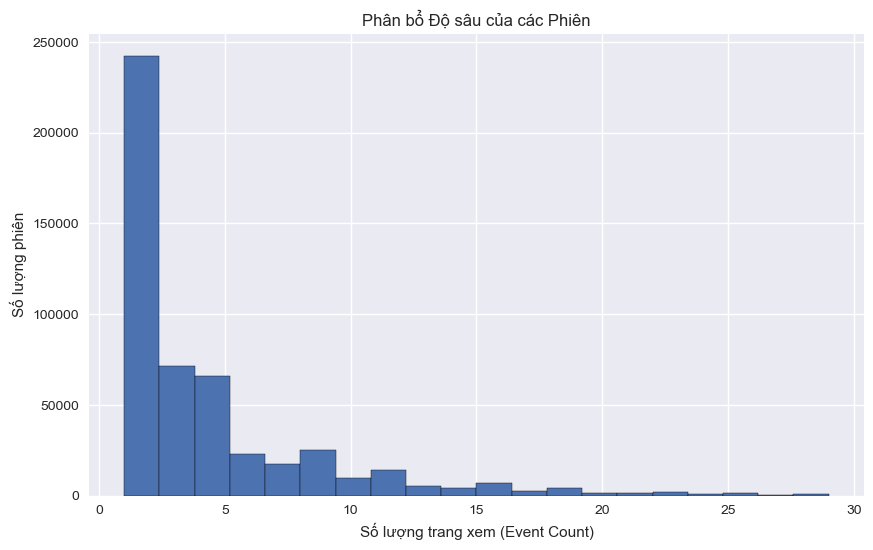

In [137]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(cleaned_journey[cleaned_journey['event_count'] < 30]['event_count'], bins=20, edgecolor='black')
plt.title('Phân bổ Độ sâu của các Phiên')
plt.xlabel('Số lượng trang xem (Event Count)')
plt.ylabel('Số lượng phiên')
plt.show()

## **Tỷ lệ Thoát (Bounce Rate) = 35.38%**

In [138]:
# 1. Đếm số lượng phiên chỉ có 1 sự kiện
num_bounces = len(cleaned_journey[cleaned_journey['event_count'] == 1])

# 2. Tổng số phiên
total_sessions = len(cleaned_journey)

# 3. Tính tỷ lệ phần trăm
bounce_rate = (num_bounces / total_sessions) * 100

print(f"Tổng số phiên: {total_sessions}")
print(f"Số phiên thoát (Bounces): {num_bounces}")
print(f"Tỷ lệ thoát (Bounce Rate): {bounce_rate:.2f}%")

Tổng số phiên: 502228
Số phiên thoát (Bounces): 203083
Tỷ lệ thoát (Bounce Rate): 40.44%


In [142]:
# 1. Đếm số lượng phiên chỉ có 1 sự kiện
num_bounces = len(session_journey[session_journey['event_count'] == 1])

# 2. Tổng số phiên
total_sessions = len(session_journey)

# 3. Tính tỷ lệ phần trăm
bounce_rate = (num_bounces / total_sessions) * 100

print(f"Tổng số phiên: {total_sessions}")
print(f"Số phiên thoát (Bounces): {num_bounces}")
print(f"Tỷ lệ thoát (Bounce Rate): {bounce_rate:.2f}%")

Tổng số phiên: 573957
Số phiên thoát (Bounces): 203083
Tỷ lệ thoát (Bounce Rate): 35.38%


## **Tốc độ Tương tác (Clicks Per Minute)**

In [143]:
# 1. Loại bỏ các phiên có duration_min = 0 để tránh lỗi chia cho 0
# (Thường là các phiên Bounce chỉ có 1 click)
active_sessions = cleaned_journey[cleaned_journey['duration_min'] > 0].copy()

# 2. Tính CPM cho từng phiên
active_sessions['cpm'] = active_sessions['event_count'] / active_sessions['duration_min']

# 3. Tính CPM trung bình trên toàn bộ dữ liệu
avg_cpm = active_sessions['cpm'].mean()

print(f"Tốc độ tương tác trung bình (Avg CPM): {avg_cpm:.2f} clicks/phút")

# 4. Xem thống kê mô tả để hiểu sự phân bổ
print("\nThống kê mô tả về CPM:")
print(active_sessions['cpm'].describe())

Tốc độ tương tác trung bình (Avg CPM): 4.75 clicks/phút

Thống kê mô tả về CPM:
count    299145.000000
mean          4.751254
std         268.631561
min           0.094993
25%           0.928674
50%           1.692439
75%           3.540371
max      120000.000000
Name: cpm, dtype: float64


## **Biểu đồ Phân tích Điểm thoát (Bar Chart - Last Action)**

/var/folders/dm/fk87zbb17nzb594pksfvrc4c0000gn/T/ipykernel_37523/2735193039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_journey, x='last_action', palette='viridis')


Text(0.5, 1.0, 'Biểu đồ Phân tích Điểm thoát (Bar Chart - Last Action)')

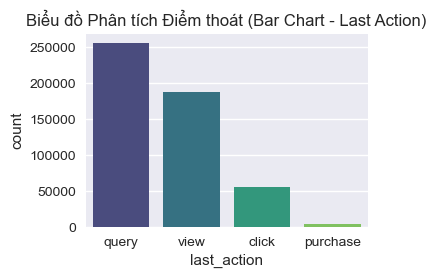

In [153]:
plt.subplot(2, 2, 3)
sns.countplot(data=cleaned_journey, x='last_action', palette='viridis')
plt.title('Biểu đồ Phân tích Điểm thoát (Bar Chart - Last Action)')

Đa số phiên kết thúc ở query mà không có view, chứng tỏ kết quả tìm kiếm chưa hấp dẫn.

In [156]:
# 1. Tạo cột hành động kế tiếp cho mỗi sessionId
all_events['next_action'] = all_events.groupby('sessionId')['action_type'].shift(-1)

# 2. Loại bỏ các dòng cuối cùng của phiên (vì không có hành động kế tiếp)
# Hoặc thay thế None bằng 'Exit' để thấy tỷ lệ thoát
all_events['next_action'] = all_events['next_action'].fillna('exit')

# 3. Đếm số lượng các cặp chuyển đổi
sankey_data = all_events.groupby(['action_type', 'next_action']).size().reset_index(name='count')

sankey_data

,action_type,next_action,count
0,click,click,187718
1,click,exit,90626
2,click,purchase,4221
3,click,query,103503
4,click,view,741696
5,purchase,click,176
6,purchase,exit,8256
7,purchase,purchase,4892
8,purchase,query,3638
9,purchase,view,1063


In [158]:
pip install --upgrade nbformat

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nbformat]
Note: you may need to restart the kernel to use updated packages.


In [160]:
pip install plotly ipywidgets --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 18.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 16.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.2 MB/s  0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [plotly]
      Successfully uninstalled plotly-5.24.1━━━━━━━━━━━━━━━━━━━━━━ 1/4 [plotly]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipywidgets]4 [plotly]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
evidently 0.7.21 requires plotly<6,>=5.10.0, but you have plotly 6.7.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [165]:
import plotly.graph_objects as go
import plotly.io as pio

# Giả sử sankey_data có các cột: action_type, next_action, count
label_list = list(set(sankey_data['action_type']).union(set(sankey_data['next_action'])))
node_map = {label: i for i, label in enumerate(label_list)}

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = label_list,
      color = "blue"
    ),
    link = dict(
      source = sankey_data['action_type'].map(node_map),
      target = sankey_data['next_action'].map(node_map),
      value = sankey_data['count']
  ))])

fig.update_layout(title_text="Hành trình người dùng trên Diginetica (Sankey Flow)", font_size=10)
pio.renderers.default = 'browser'
fig.show()

## **Phễu Chuyển đổi (Conversion Funnel)**

## **Giá trị Đơn hàng Trung bình (Average order value) = 361.23$**

In [183]:
# Chuyển đổi giá trong bảng products
products['actual_price'] = 2 ** products['pricelog2']

In [184]:
products

,itemId,pricelog2,product.name.tokens,actual_price
0,1,10,"4875,776,56689,18212,18212,4896",1024
1,69585,6,"7583,18117,41805,41805,2371",64
2,90939,6,"604,18117,41805,41805,2371",64
3,69586,0,"2936,18117,41805,41805,2371",1
4,30029,7,"4668,41805,41805,56652",128
...,...,...,...,...
184042,381997,8,"134345,135203,3583,2886,103395",256
184043,402737,9,"527890,527815,527815,183393,277935,19123",512
184044,388028,10,"527953,15027,15027,527952",1024
184045,424367,9,"360922,528327,52648,52648,514247",512


In [185]:
# Liên kết bảng purchases với giá sản phẩm
purchase_data = pd.merge(purchases, products[['itemId', 'actual_price']], on='itemId', how='left')

In [186]:
purchase_data

,sessionId,userId,timeframe,eventdate,ordernumber,itemId,actual_price
0,150,18278.0,17100868,2016-05-06,16421,25911,512
1,151,NaN,6454547,2016-05-06,16290,175874,1
2,156,7.0,1721689387,2016-05-27,21173,35324,1024
3,179,NaN,343001,2016-05-09,16924,31233,256
4,246,34.0,2311046,2016-05-09,16936,34677,128
...,...,...,...,...,...,...,...
18020,600131,NaN,3674676,2016-03-18,5675,40804,128
18021,600250,NaN,4943513,2016-05-21,19629,33777,256
18022,600432,NaN,205120,2016-04-25,13928,17176,128
18023,600432,NaN,205120,2016-04-25,13928,13662,256


In [187]:
# Tính AOV = Tổng doanh thu / Tổng số đơn hàng (ordernumber)
total_revenue = purchase_data['actual_price'].sum()
total_orders = purchase_data['ordernumber'].nunique()
aov = total_revenue / total_orders
print(f"Average Order Value: {aov:.2f}")

Average Order Value: 361.23


In [190]:
total_revenue

np.int64(4878715)

In [191]:
total_orders

13506

## **Conversion Rate - CVR = 2.20%**

In [188]:
# Số phiên có mua hàng
purchasing_sessions = purchases['sessionId'].nunique()

cvr = (purchasing_sessions / total_sessions) * 100
print(f"Conversion Rate (CVR): {cvr:.2f}%")

Conversion Rate (CVR): 2.20%


## **Doanh thu trên mỗi Phiên (Revenue per Session) = 8.50$**


In [189]:
revenue_per_session = total_revenue / total_sessions
print(f"Revenue per Session: {revenue_per_session:.2f}")

Revenue per Session: 8.50
